# 03 — Weather and TimePeriod

The thermal-comfort analyses (UTCI, TCS) and the solar-radiation
analysis are weather-driven. Workflow:

1. Find the closest weather station for your lat/lon.
2. Filter that station's typical-meteorological-year (TMY) data to a
   `TimePeriod` (months/days/hours of interest).
3. Pass the same `TimePeriod` and the filtered weather data into the
   analysis payload.

Step 3 is critical -- the same `TimePeriod` instance must be used in
both `filter_weather_data` and the analysis payload, or you get
silently misaligned arrays.

In [1]:
from dotenv import load_dotenv

load_dotenv()

from infrared_sdk import InfraredClient
from infrared_sdk.models import TimePeriod, extract_weather_fields
from cities import get

city = get("munich")

## 1. Find a station

In [2]:
with InfraredClient() as client:
    stations = client.weather.get_weather_file_from_location(
        lat=city.latitude,
        lon=city.longitude,
        radius=50,  # km
    )

print(f"found {len(stations)} station(s) within 50 km")
for s in stations[:3]:
    print(f"  {s.get('identifier') or s.get('uuid')}  ({s.get('city', '?')})")
weather_id = stations[0].get("identifier") or stations[0].get("uuid")

found 8 station(s) within 50 km
  eb91892c-fbe3-4743-ade5-c22cfb5913e1  (?)
  68c34eae-f3af-4d77-9491-61e116c80efc  (?)
  016817c9-66f6-415a-b3a2-615181133b86  (?)


## 2. Filter to a time window

`TimePeriod` selects an inclusive month/day/hour-of-year window from the
TMY file. Hours are 0-23. The window can wrap years if you want
multi-month spans.

In [3]:
# A summer afternoon sample: Jun-Aug, 12:00-17:00 every day.
tp = TimePeriod(
    start_month=6,
    start_day=1,
    start_hour=12,
    end_month=8,
    end_day=31,
    end_hour=17,
)

with InfraredClient() as client:
    weather = client.weather.filter_weather_data(identifier=weather_id, time_period=tp)

print(f"{len(weather)} weather points returned")
sample = weather[0]
print(f"sample dryBulbTemperature : {sample.dryBulbTemperature}")
print(f"sample windSpeed          : {sample.windSpeed}")
print(f"sample directNormalRadiation : {sample.directNormalRadiation}")

552 weather points returned
sample dryBulbTemperature : 13.0
sample windSpeed          : 8.4
sample directNormalRadiation : 426.0


## 3. Visualise the window

A quick sanity-check plot: temperature distribution across the filter window.

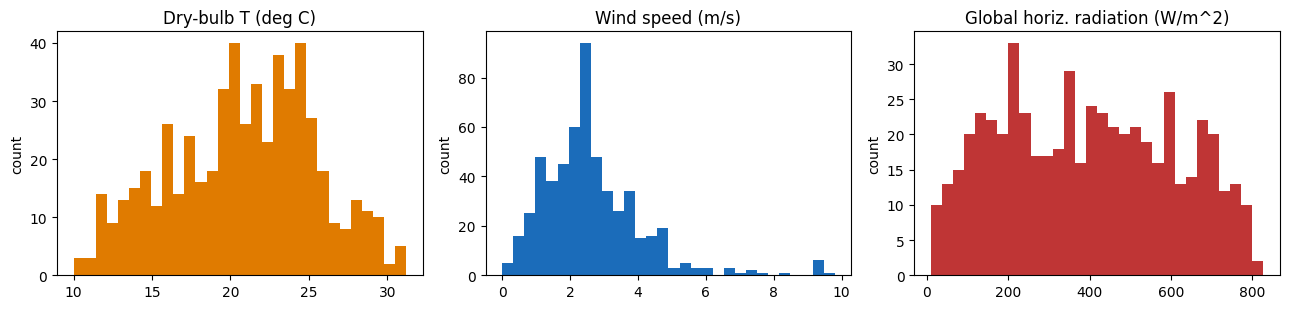

In [4]:
import matplotlib.pyplot as plt

temps = [p.dryBulbTemperature for p in weather if p.dryBulbTemperature is not None]
winds = [p.windSpeed for p in weather if p.windSpeed is not None]
ghr = [
    p.globalHorizontalRadiation
    for p in weather
    if p.globalHorizontalRadiation is not None
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].hist(temps, bins=30, color="#e07b00")
axes[0].set_title("Dry-bulb T (deg C)")
axes[1].hist(winds, bins=30, color="#1b6cba")
axes[1].set_title("Wind speed (m/s)")
axes[2].hist(ghr, bins=30, color="#bf3535")
axes[2].set_title("Global horiz. radiation (W/m^2)")
for ax in axes:
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 4. Extract fields for an analysis payload

`extract_weather_fields` pulls the named fields into flat lists keyed
by snake_case names so you can splat them into a payload:

In [5]:
fields = extract_weather_fields(weather, ["windSpeed", "windDirection"])
print(list(fields.keys()))
print(f"wind_speed : {len(fields['wind_speed'])} samples")
print(f"first 5    : {fields['wind_speed'][:5]}")

['wind_speed', 'wind_direction']
wind_speed : 552 samples
first 5    : [8.4, 9.3, 9.3, 9.3, 9.3]


You'll see this exact pattern in `05_analysis_types_tour.ipynb` when we
build a `PwcModelRequest` from filtered weather data, and in the UTCI / TCS /
Solar Radiation factories that take `weather_data` directly.

> **TimePeriod gotcha.** If you change the `TimePeriod` for the analysis
> payload but reuse the original filtered list, the array lengths won't
> match the API's expectations. Always re-filter when you change the
> window.